In [ ]:
# =====================================================================
# CLASS ĐÁNH GIÁ INFORMATION RETRIEVAL (IR)
# =====================================================================
# Mục đích: Đánh giá hiệu suất của mô hình embedding trong bài toán tìm kiếm thông tin
# Input: Queries (câu hỏi), Corpus (tài liệu), Relevant_docs (tài liệu đúng)
# Output: Các metrics đo lường hiệu suất (Accuracy, Precision, Recall, MRR, NDCG, MAP)
# =====================================================================

from __future__ import annotations

import heapq
import json
import logging
import os
from typing import TYPE_CHECKING, Callable

import numpy as np
import torch
from torch import Tensor
from tqdm import trange

from sentence_transformers.evaluation.SentenceEvaluator import SentenceEvaluator
from sentence_transformers.similarity_functions import SimilarityFunction

if TYPE_CHECKING:
    from sentence_transformers.SentenceTransformer import SentenceTransformer

logger = logging.getLogger(__name__)


class InformationRetrievalEvaluator(SentenceEvaluator):
    """
    Class đánh giá hiệu suất Information Retrieval (IR).
    
     CÁCH HOẠT ĐỘNG:
    1. Nhận đầu vào: Queries (câu hỏi), Corpus (tài liệu), Ground truth (tài liệu đúng)
    2. Mã hóa queries và corpus thành embeddings
    3. Tính similarity giữa mỗi query và tất cả documents
    4. Lấy Top-K documents có similarity cao nhất
    5. So sánh với ground truth và tính các metrics
    
     CÁC METRICS ĐƯỢC TÍNH:
    - Accuracy@k: Tỷ lệ queries tìm được ít nhất 1 doc đúng trong Top-K
    - Precision@k: Tỷ lệ documents đúng trong K kết quả trả về
    - Recall@k: Tỷ lệ documents đúng được tìm thấy
    - MRR@k: Vị trí trung bình của document đúng đầu tiên
    - NDCG@k: Chất lượng xếp hạng (ranking quality)
    - MAP@k: Mean Average Precision - chất lượng tổng thể
    """

    def __init__(
        self,
        queries: dict[str, str],  # qid => query text
        corpus: dict[str, str],  # doc_id => document text
        relevant_docs: dict[str, set[str]],  # qid => Set[doc_id đúng]
        corpus_chunk_size: int = 50000,  # Xử lý corpus theo chunks để tiết kiệm RAM
        mrr_at_k: list[int] = [10],
        ndcg_at_k: list[int] = [10],
        accuracy_at_k: list[int] = [1, 3, 5, 10],
        precision_recall_at_k: list[int] = [1, 3, 5, 10],
        map_at_k: list[int] = [100],
        show_progress_bar: bool = False,
        batch_size: int = 32,
        name: str = "",
        write_csv: bool = True,
        truncate_dim: int | None = None,
        score_functions: dict[str, Callable[[Tensor, Tensor], Tensor]] | None = None,
        main_score_function: str | SimilarityFunction | None = None,
        query_prompt: str | None = None,
        query_prompt_name: str | None = None,
        corpus_prompt: str | None = None,
        corpus_prompt_name: str | None = None,
        write_predictions: bool = False,
    ) -> None:
        """
        Khởi tạo evaluator với queries, corpus và ground truth.
        
        Args:
            queries: Dictionary ánh xạ query_id -> query_text
            corpus: Dictionary ánh xạ doc_id -> document_text
            relevant_docs: Dictionary ánh xạ query_id -> set(doc_ids đúng)
            corpus_chunk_size: Số documents xử lý mỗi lần (tránh out of memory)
            *_at_k: Các giá trị K để tính metrics (@1, @5, @10...)
        """
        super().__init__()
        
        # ===== BƯỚC 1: LỌC QUERIES HỢP LỆ =====
        # Chỉ giữ lại queries có ít nhất 1 document đúng
        self.queries_ids = []
        for qid in queries:
            if qid in relevant_docs and len(relevant_docs[qid]) > 0:
                self.queries_ids.append(qid)

        self.queries = [queries[qid] for qid in self.queries_ids]

        # ===== BƯỚC 2: CHUẨN BỊ CORPUS =====
        self.corpus_ids = list(corpus.keys())
        self.corpus = [corpus[cid] for cid in self.corpus_ids]

        # ===== BƯỚC 3: LƯU CÁC THAM SỐ =====
        self.query_prompt = query_prompt
        self.query_prompt_name = query_prompt_name
        self.corpus_prompt = corpus_prompt
        self.corpus_prompt_name = corpus_prompt_name

        self.relevant_docs = relevant_docs
        self.corpus_chunk_size = corpus_chunk_size
        self.mrr_at_k = mrr_at_k
        self.ndcg_at_k = ndcg_at_k
        self.accuracy_at_k = accuracy_at_k
        self.precision_recall_at_k = precision_recall_at_k
        self.map_at_k = map_at_k

        self.show_progress_bar = show_progress_bar
        self.batch_size = batch_size
        self.name = name
        self.write_csv = write_csv
        self.score_functions = score_functions
        self.score_function_names = sorted(list(self.score_functions.keys())) if score_functions else []
        self.main_score_function = SimilarityFunction(main_score_function) if main_score_function else None
        self.truncate_dim = truncate_dim

        # ===== BƯỚC 4: CẤU HÌNH FILE OUTPUT =====
        if name:
            name = "_" + name

        self.csv_file: str = "Information-Retrieval_evaluation" + name + "_results.csv"
        self.csv_headers = ["epoch", "steps"]

        self._append_csv_headers(self.score_function_names)
        self.write_predictions = write_predictions
        if self.write_predictions:
            self.predictions_file = "Information-Retrieval_evaluation" + name + "_predictions.jsonl"

    def _append_csv_headers(self, score_function_names):
        """
        Tạo headers cho file CSV kết quả.
        
        Format: [epoch, steps, Accuracy@1, Accuracy@3, ..., Precision@1, ...]
        """
        for score_name in score_function_names:
            for k in self.accuracy_at_k:
                self.csv_headers.append(f"{score_name}-Accuracy@{k}")

            for k in self.precision_recall_at_k:
                self.csv_headers.append(f"{score_name}-Precision@{k}")
                self.csv_headers.append(f"{score_name}-Recall@{k}")

            for k in self.mrr_at_k:
                self.csv_headers.append(f"{score_name}-MRR@{k}")

            for k in self.ndcg_at_k:
                self.csv_headers.append(f"{score_name}-NDCG@{k}")

            for k in self.map_at_k:
                self.csv_headers.append(f"{score_name}-MAP@{k}")

    def __call__(
        self,
        model: SentenceTransformer,
        output_path: str | None = None,
        epoch: int = -1,
        steps: int = -1,
        *args,
        **kwargs,
    ) -> dict[str, float]:
        """
        HÀM CHÍNH: Thực hiện đánh giá model và trả về kết quả.
        
        FLOW:
        1. Tính toán các metrics (gọi compute_metrices)
        2. Ghi kết quả ra file CSV
        3. Xác định primary_metric (metric quan trọng nhất)
        4. Trả về dictionary chứa tất cả metrics
        
        Returns:
            dict: {metric_name: value} - Ví dụ: {"cosine_accuracy@1": 0.85, ...}
        """
        # ===== LOG THÔNG TIN =====
        if epoch != -1:
            if steps == -1:
                out_txt = f" after epoch {epoch}"
            else:
                out_txt = f" in epoch {epoch} after {steps} steps"
        else:
            out_txt = ""
        if self.truncate_dim is not None:
            out_txt += f" (truncated to {self.truncate_dim})"

        logger.info(f"Information Retrieval Evaluation of the model on the {self.name} dataset{out_txt}:")

        # ===== KHỞI TẠO SCORE FUNCTIONS =====
        if self.score_functions is None:
            self.score_functions = {model.similarity_fn_name: model.similarity}
            self.score_function_names = [model.similarity_fn_name]
            self._append_csv_headers(self.score_function_names)

        # ===== BƯỚC CHÍNH: TÍNH TOÁN METRICS =====
        scores = self.compute_metrices(model, output_path=output_path, *args, **kwargs)

        # ===== GHI KẾT QUẢ RA FILE CSV =====
        if output_path is not None and self.write_csv:
            os.makedirs(output_path, exist_ok=True)
            csv_path = os.path.join(output_path, self.csv_file)
            
            # Tạo file mới nếu chưa tồn tại
            if not os.path.isfile(csv_path):
                fOut = open(csv_path, mode="w", encoding="utf-8")
                fOut.write(",".join(self.csv_headers))
                fOut.write("\n")
            else:
                fOut = open(csv_path, mode="a", encoding="utf-8")

            # Ghi dữ liệu metrics
            output_data = [epoch, steps]
            for name in self.score_function_names:
                for k in self.accuracy_at_k:
                    output_data.append(scores[name]["accuracy@k"][k])

                for k in self.precision_recall_at_k:
                    output_data.append(scores[name]["precision@k"][k])
                    output_data.append(scores[name]["recall@k"][k])

                for k in self.mrr_at_k:
                    output_data.append(scores[name]["mrr@k"][k])

                for k in self.ndcg_at_k:
                    output_data.append(scores[name]["ndcg@k"][k])

                for k in self.map_at_k:
                    output_data.append(scores[name]["map@k"][k])

            fOut.write(",".join(map(str, output_data)))
            fOut.write("\n")
            fOut.close()

        # ===== XÁC ĐỊNH PRIMARY METRIC =====
        # Primary metric: Metric quan trọng nhất để so sánh models
        if not self.primary_metric:
            if self.main_score_function is None:
                # Mặc định: Chọn NDCG@k lớn nhất
                score_function = max(
                    [(name, scores[name]["ndcg@k"][max(self.ndcg_at_k)]) for name in self.score_function_names],
                    key=lambda x: x[1],
                )[0]
                self.primary_metric = f"{score_function}_ndcg@{max(self.ndcg_at_k)}"
            else:
                self.primary_metric = f"{self.main_score_function.value}_ndcg@{max(self.ndcg_at_k)}"

        # ===== FLATTEN METRICS THÀNH DICT PHẲNG =====
        metrics = {
            f"{score_function}_{metric_name.replace('@k', '@' + str(k))}": value
            for score_function, values_dict in scores.items()
            for metric_name, values in values_dict.items()
            for k, value in values.items()
        }
        metrics = self.prefix_name_to_metrics(metrics, self.name)
        self.store_metrics_in_model_card_data(model, metrics, epoch, steps)
        return metrics

    def compute_metrices(
        self,
        model: SentenceTransformer,
        corpus_model=None,
        corpus_embeddings: Tensor | None = None,
        output_path: str | None = None,
    ) -> dict[str, float]:
        """
        TÍNH TOÁN CÁC METRICS .
        
        THUẬT TOÁN:
        1. Encode tất cả queries thành embeddings
        2. Lặp qua từng chunk của corpus:
           a. Encode chunk đó thành embeddings
           b. Tính similarity giữa queries và chunk
           c. Lấy Top-K results cho mỗi query
           d. Lưu vào heap để track Top-K tốt nhất
        3. Tính các metrics dựa trên Top-K results và ground truth
        
        Returns:
            dict: {score_function: {metric_name: {k: value}}}
            Ví dụ: {"cosine": {"accuracy@k": {1: 0.8, 5: 0.95}, ...}}
        """
        if corpus_model is None:
            corpus_model = model

        # ===== XÁC ĐỊNH K LỚN NHẤT =====
        max_k = max(
            max(self.mrr_at_k),
            max(self.ndcg_at_k),
            max(self.accuracy_at_k),
            max(self.precision_recall_at_k),
            max(self.map_at_k),
        )

        # ===== BƯỚC 1: ENCODE TẤT CẢ QUERIES =====
        # Chuyển đổi queries thành vectors (embeddings)
        query_embeddings = self.embed_inputs(
            model,
            self.queries,
            encode_fn_name="query",
            prompt_name=self.query_prompt_name,
            prompt=self.query_prompt,
        )

        # ===== KHỞI TẠO DANH SÁCH KẾT QUẢ =====
        # queries_result_list[score_fn][query_idx] = [(score, doc_id), ...]
        queries_result_list = {}
        for name in self.score_functions:
            queries_result_list[name] = [[] for _ in range(len(query_embeddings))]

        # ===== BƯỚC 2: XỬ LÝ TỪNG CHUNK CỦA CORPUS =====
        for corpus_start_idx in trange(
            0, len(self.corpus), self.corpus_chunk_size, desc="Corpus Chunks", disable=not self.show_progress_bar
        ):
            corpus_end_idx = min(corpus_start_idx + self.corpus_chunk_size, len(self.corpus))

            # Encode chunk hiện tại
            if corpus_embeddings is None:
                sub_corpus_embeddings = self.embed_inputs(
                    corpus_model,
                    self.corpus[corpus_start_idx:corpus_end_idx],
                    encode_fn_name="document",
                    prompt_name=self.corpus_prompt_name,
                    prompt=self.corpus_prompt,
                )
            else:
                sub_corpus_embeddings = corpus_embeddings[corpus_start_idx:corpus_end_idx]

            # ===== TÍNH SIMILARITY VÀ LẤY TOP-K =====
            for name, score_function in self.score_functions.items():
                # Tính similarity matrix: [num_queries x num_docs_in_chunk]
                pair_scores = score_function(query_embeddings, sub_corpus_embeddings)

                # Lấy Top-K documents có điểm cao nhất
                pair_scores_top_k_values, pair_scores_top_k_idx = torch.topk(
                    pair_scores, min(max_k, len(pair_scores[0])), dim=1, largest=True, sorted=False
                )
                pair_scores_top_k_values = pair_scores_top_k_values.cpu().tolist()
                pair_scores_top_k_idx = pair_scores_top_k_idx.cpu().tolist()

                # ===== SỬ DỤNG HEAP ĐỂ TRACK TOP-K TỐT NHẤT =====
                for query_itr in range(len(query_embeddings)):
                    for sub_corpus_id, score in zip(
                        pair_scores_top_k_idx[query_itr], pair_scores_top_k_values[query_itr]
                    ):
                        corpus_id = self.corpus_ids[corpus_start_idx + sub_corpus_id]
                        
                        # Sử dụng heap để luôn giữ Top-K kết quả tốt nhất
                        if len(queries_result_list[name][query_itr]) < max_k:
                            heapq.heappush(queries_result_list[name][query_itr], (score, corpus_id))
                        else:
                            # Thay thế phần tử nhỏ nhất nếu tìm thấy score cao hơn
                            heapq.heappushpop(queries_result_list[name][query_itr], (score, corpus_id))

        # ===== CHUYỂN ĐỔI KẾT QUẢ SANG FORMAT DICT =====
        for name in queries_result_list:
            for query_itr in range(len(queries_result_list[name])):
                for doc_itr in range(len(queries_result_list[name][query_itr])):
                    score, corpus_id = queries_result_list[name][query_itr][doc_itr]
                    queries_result_list[name][query_itr][doc_itr] = {"corpus_id": corpus_id, "score": score}

        # ===== GHI DỰ ĐOÁN RA FILE (NẾU CẦN) =====
        if self.write_predictions and output_path is not None:
            for name in queries_result_list:
                base_filename = self.predictions_file.replace(".jsonl", f"_{name}.jsonl")
                json_path = os.path.join(output_path, base_filename)
                mode = "w"

                with open(json_path, mode=mode, encoding="utf-8") as fOut:
                    for query_itr in range(len(queries_result_list[name])):
                        query_id = self.queries_ids[query_itr]
                        query_text = self.queries[query_itr]
                        results = queries_result_list[name][query_itr]

                        # Sắp xếp theo điểm giảm dần
                        results = sorted(results, key=lambda x: x["score"], reverse=True)

                        prediction = {
                            "query_id": query_id,
                            "query": query_text,
                            "results": results,
                        }

                        fOut.write(json.dumps(prediction) + "\n")

        logger.info(f"Queries: {len(self.queries)}")
        logger.info(f"Corpus: {len(self.corpus)}\n")

        # ===== BƯỚC 3: TÍNH CÁC METRICS =====
        scores = {name: self.compute_metrics(queries_result_list[name]) for name in self.score_functions}

        # Output kết quả ra console
        for name in self.score_function_names:
            logger.info(f"Score-Function: {name}")
            self.output_scores(scores[name])

        return scores

    def embed_inputs(
        self,
        model: SentenceTransformer,
        sentences: str | list[str] | np.ndarray,
        encode_fn_name: str | None = None,
        prompt_name: str | None = None,
        prompt: str | None = None,
        **kwargs,
    ) -> np.ndarray:
        """
        Mã hóa văn bản thành embeddings (vectors).
        
        Args:
            sentences: Danh sách văn bản cần encode
            encode_fn_name: "query" hoặc "document" (cho models có encode riêng)
            
        Returns:
            Tensor: Embeddings có shape [num_sentences, embedding_dim]
        """
        if encode_fn_name is None:
            encode_fn = model.encode
        elif encode_fn_name == "query":
            encode_fn = model.encode_query
        elif encode_fn_name == "document":
            encode_fn = model.encode_document
            
        return encode_fn(
            sentences,
            prompt_name=prompt_name,
            prompt=prompt,
            batch_size=self.batch_size,
            show_progress_bar=self.show_progress_bar,
            convert_to_tensor=True,
            truncate_dim=self.truncate_dim,
            **kwargs,
        )

    def compute_metrics(self, queries_result_list: list[object]):
        """
        TÍNH TOÁN CÁC METRICS DỰA TRÊN TOP-K RESULTS VÀ GROUND TRUTH.
        
        LOGIC TÍNH TOÁN:
        
         ACCURACY@k:
        - Đếm số queries có ít nhất 1 doc đúng trong Top-K
        - Formula: (Số queries tìm được doc đúng) / (Tổng số queries)
        
         PRECISION@k:
        - Tỷ lệ docs đúng trong K kết quả trả về
        - Formula: (Số docs đúng trong Top-K) / K
        
         RECALL@k:
        - Tỷ lệ docs đúng được tìm thấy so với tổng số docs đúng
        - Formula: (Số docs đúng tìm được) / (Tổng docs đúng của query)
        
         MRR@k (Mean Reciprocal Rank):
        - Vị trí trung bình của doc đúng đầu tiên
        - Formula: trung_bình(1 / rank_của_doc_đúng_đầu_tiên)
        - Ví dụ: Doc đúng ở vị trí 3 → MRR = 1/3 = 0.333
        
         NDCG@k (Normalized Discounted Cumulative Gain):
        - Đánh giá chất lượng ranking (docs đúng càng ở trên càng tốt)
        - Formula: DCG / Ideal_DCG
        - DCG = Σ(relevance[i] / log2(i+2))
        
         MAP@k (Mean Average Precision):
        - Trung bình Precision tại các vị trí có doc đúng
        - Formula: trung_bình(Σ(Precision@i * is_relevant[i]))
        
        Returns:
            dict: {
                "accuracy@k": {1: 0.8, 5: 0.9, ...},
                "precision@k": {...},
                "recall@k": {...},
                "mrr@k": {...},
                "ndcg@k": {...},
                "map@k": {...}
            }
        """
        # ===== KHỞI TẠO BIẾN LƯU TRỮ =====
        num_hits_at_k = {k: 0 for k in self.accuracy_at_k}
        precisions_at_k = {k: [] for k in self.precision_recall_at_k}
        recall_at_k = {k: [] for k in self.precision_recall_at_k}
        MRR = {k: 0 for k in self.mrr_at_k}
        ndcg = {k: [] for k in self.ndcg_at_k}
        AveP_at_k = {k: [] for k in self.map_at_k}

        # ===== LẶP QUA TỪNG QUERY =====
        for query_itr in range(len(queries_result_list)):
            query_id = self.queries_ids[query_itr]

            # Sắp xếp kết quả theo điểm giảm dần
            top_hits = sorted(queries_result_list[query_itr], key=lambda x: x["score"], reverse=True)
            query_relevant_docs = self.relevant_docs[query_id]

            # ===== 1 TÍNH ACCURACY@k =====
            # Đếm là đúng nếu có ít nhất 1 doc đúng trong Top-K
            for k_val in self.accuracy_at_k:
                for hit in top_hits[0:k_val]:
                    if hit["corpus_id"] in query_relevant_docs:
                        num_hits_at_k[k_val] += 1
                        break  # Chỉ cần 1 doc đúng là đủ

            # ===== 2 TÍNH PRECISION & RECALL@k =====
            for k_val in self.precision_recall_at_k:
                num_correct = 0
                for hit in top_hits[0:k_val]:
                    if hit["corpus_id"] in query_relevant_docs:
                        num_correct += 1

                # Precision: Tỷ lệ docs đúng trong K kết quả
                precisions_at_k[k_val].append(num_correct / k_val)
                
                # Recall: Tỷ lệ docs đúng được tìm thấy
                recall_at_k[k_val].append(num_correct / len(query_relevant_docs))

            # ===== 3 TÍNH MRR@k =====
            # Tìm vị trí của doc đúng đầu tiên
            for k_val in self.mrr_at_k:
                for rank, hit in enumerate(top_hits[0:k_val]):
                    if hit["corpus_id"] in query_relevant_docs:
                        MRR[k_val] += 1.0 / (rank + 1)  # rank bắt đầu từ 0 → +1
                        break

            # ===== 4 TÍNH NDCG@k =====
            # Đánh giá chất lượng ranking
            for k_val in self.ndcg_at_k:
                # Tạo list relevance: 1 nếu đúng, 0 nếu sai
                predicted_relevance = [
                    1 if top_hit["corpus_id"] in query_relevant_docs else 0 
                    for top_hit in top_hits[0:k_val]
                ]
                # Ideal ranking: Tất cả docs đúng xếp đầu
                true_relevances = [1] * len(query_relevant_docs)

                # NDCG = DCG(predicted) / DCG(ideal)
                ndcg_value = self.compute_dcg_at_k(predicted_relevance, k_val) / self.compute_dcg_at_k(
                    true_relevances, k_val
                )
                ndcg[k_val].append(ndcg_value)

            # ===== 5 TÍNH MAP@k =====
            # Mean Average Precision
            for k_val in self.map_at_k:
                num_correct = 0
                sum_precisions = 0

                for rank, hit in enumerate(top_hits[0:k_val]):
                    if hit["corpus_id"] in query_relevant_docs:
                        num_correct += 1
                        # Cộng dồn Precision tại vị trí này
                        sum_precisions += num_correct / (rank + 1)
                        
                # Average Precision cho query này
                avg_precision = sum_precisions / min(k_val, len(query_relevant_docs))
                AveP_at_k[k_val].append(avg_precision)

        # ===== TÍNH TRUNG BÌNH CHO TẤT CẢ QUERIES =====
        for k in num_hits_at_k:
            num_hits_at_k[k] /= len(self.queries)

        for k in precisions_at_k:
            precisions_at_k[k] = np.mean(precisions_at_k[k])

        for k in recall_at_k:
            recall_at_k[k] = np.mean(recall_at_k[k])

        for k in ndcg:
            ndcg[k] = np.mean(ndcg[k])

        for k in MRR:
            MRR[k] /= len(self.queries)

        for k in AveP_at_k:
            AveP_at_k[k] = np.mean(AveP_at_k[k])

        return {
            "accuracy@k": num_hits_at_k,
            "precision@k": precisions_at_k,
            "recall@k": recall_at_k,
            "ndcg@k": ndcg,
            "mrr@k": MRR,
            "map@k": AveP_at_k,
        }

    def output_scores(self, scores):
        """In kết quả metrics ra console."""
        for k in scores["accuracy@k"]:
            logger.info("Accuracy@{}: {:.2f}%".format(k, scores["accuracy@k"][k] * 100))

        for k in scores["precision@k"]:
            logger.info("Precision@{}: {:.2f}%".format(k, scores["precision@k"][k] * 100))

        for k in scores["recall@k"]:
            logger.info("Recall@{}: {:.2f}%".format(k, scores["recall@k"][k] * 100))

        for k in scores["mrr@k"]:
            logger.info("MRR@{}: {:.4f}".format(k, scores["mrr@k"][k]))

        for k in scores["ndcg@k"]:
            logger.info("NDCG@{}: {:.4f}".format(k, scores["ndcg@k"][k]))

        for k in scores["map@k"]:
            logger.info("MAP@{}: {:.4f}".format(k, scores["map@k"][k]))

    @staticmethod
    def compute_dcg_at_k(relevances, k):
        """
        Tính DCG (Discounted Cumulative Gain) - Thành phần của NDCG.
        
        CÔNG THỨC DCG:
        DCG@k = Σ(relevance[i] / log2(i + 2))
        
        GIẢI THÍCH:
        - relevances[i]: 1 nếu doc ở vị trí i đúng, 0 nếu sai
        - log2(i+2): Hệ số giảm dần theo vị trí (vị trí càng xa, trọng số càng thấp)
        - +2 vì index bắt đầu từ 0: log2(0+2)=1, log2(1+2)≈1.58, log2(2+2)=2...
        
        VÍ DỤ:
        - [1,1,0,0,1] → DCG = 1/log2(2) + 1/log2(3) + 0 + 0 + 1/log2(6)
        - [1,1,1,1,1] → DCG = Ideal (tất cả docs đúng xếp đầu)
        
        Args:
            relevances: List [1,0,1,...] - 1 là đúng, 0 là sai
            k: Số lượng positions để tính
            
        Returns:
            float: DCG score
        """
        dcg = 0
        for i in range(min(len(relevances), k)):
            dcg += relevances[i] / np.log2(i + 2)  # +2 vì index bắt đầu từ 0
        return dcg

    def get_config_dict(self):
        """Lấy cấu hình evaluator để lưu vào model card."""
        config_dict = {}
        config_dict_candidate_keys = [
            "truncate_dim",
            "query_prompt",
            "query_prompt_name",
            "corpus_prompt",
            "corpus_prompt_name",
        ]
        for key in config_dict_candidate_keys:
            if getattr(self, key) is not None:
                config_dict[key] = getattr(self, key)
        return config_dict

C:\Users\Acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# =====================================================================
# SCRIPT ĐÁNH GIÁ MÔ HÌNH EMBEDDING CHO HỆ THỐNG RAG
# =====================================================================
# Mục đích: So sánh hiệu suất giữa mô hình Base và Fine-tuned
# Phương pháp: Sử dụng Information Retrieval Evaluation
# =====================================================================

# --- TRÁNH LỖI additional_chat_templates ---
import os
os.environ["TRANSFORMERS_NO_ADDITIONAL_CHAT_TEMPLATES"] = "1"

import os
import pickle
from sentence_transformers import SentenceTransformer
from sentence_transformers.evaluation import InformationRetrievalEvaluator

# ===== 1️⃣ LOAD TEST DATA (.pkl) =====
pkl_path = r"D:\ARTIFICIAL_INTELLIGENCE\KY_9\AIP491\AIP491_G9\Data\data_train\data_train_v2\test_pairs_v2.pkl"

with open(pkl_path, "rb") as f:
    test_pairs = pickle.load(f)

print("✅ Số mẫu test:", len(test_pairs))

# ===== 2️⃣ TẠO QUERIES / CORPUS / QRELS (Ground Truth) =====
# Queries: Các câu hỏi cần tìm kiếm
# Corpus: Cơ sở dữ liệu văn bản (các đoạn document)
# Qrels (Query Relevance): Ánh xạ câu hỏi -> tài liệu liên quan (ground truth)

def ensure_prefix(s: str, kind: str) -> str:
    """
    Đảm bảo văn bản có prefix đúng định dạng (query: hoặc passage:)
    Quan trọng với các mô hình như E5 yêu cầu prefix để phân biệt query/document
    """
    import re
    s = re.sub(fr"^{kind}:\s*{kind}:\s*", f"{kind}: ", s, flags=re.I)
    return s if s.lower().startswith(f"{kind}:") else f"{kind}: {s}"

def build_ir_inputs(pairs):
    """
    Chuyển đổi test_pairs sang format chuẩn của InformationRetrievalEvaluator:
    - queries: dict {query_id: query_text}
    - corpus: dict {doc_id: document_text}
    - qrels: dict {query_id: set([relevant_doc_ids])}
    """
    queries, corpus, qrels = {}, {}, {}
    for i, ex in enumerate(pairs):
        if len(ex.texts) != 2:
            continue
        q = ensure_prefix(ex.texts[0].strip(), "query")
        p = ensure_prefix(ex.texts[1].strip(), "passage")
        qid, did = f"q{i}", f"d{i}"
        queries[qid] = q
        corpus[did] = p
        qrels[qid] = {did}  # Mỗi query chỉ có 1 document liên quan (1-to-1 mapping)
    return queries, corpus, qrels

queries, corpus, qrels = build_ir_inputs(test_pairs)

print(f"📊 Queries: {len(queries)} | Corpus: {len(corpus)} | Qrels: {len(qrels)}")

# ===== 3️⃣ LOAD MODELS (Base vs Fine-tuned) =====
BASE_MODEL = "intfloat/multilingual-e5-base"
# Các lựa chọn khác:
# - bkai-foundation-models/vietnamese-bi-encoder
# - sentence-transformers/all-mpnet-base-v2
# - hiieu/halong_embedding

FT_MODEL_DIR = r"d:\ARTIFICIAL_INTELLIGENCE\KY_9\AIP491\model_train\intfloat-multilingual-e5-base_fine_tuning_v2"

print("\n Đang tải model base...")
model_base = SentenceTransformer(BASE_MODEL)

print(" Đang tải model fine-tuned...")
model_ft = SentenceTransformer(FT_MODEL_DIR)

# ===== 4 TẠO EVALUATOR VỚI CÁC CHỈ SỐ ĐÁNH GIÁ =====
# =====================================================================
#  GIẢI THÍCH CÁC CHỈ SỐ ĐÁNH GIÁ (METRICS)
# =====================================================================
#
# 1 ACCURACY@k (Độ chính xác tìm kiếm)
#    - Tỷ lệ câu hỏi có ít nhất 1 tài liệu đúng trong Top-K kết quả
#    - Ví dụ: Acc@5 = 0.8 nghĩa là 80% câu hỏi tìm được đáp án đúng trong Top 5
#    - Quan trọng nhất: Acc@1 (có tìm được đúng ở vị trí đầu tiên không?)
#
# 2 PRECISION@k (Độ chính xác của tập trả về)
#    - Tỷ lệ tài liệu liên quan trong K kết quả trả về
#    - Công thức: (Số tài liệu đúng trong Top-K) / K
#    - Ví dụ: P@10 = 0.6 nghĩa là trong 10 kết quả trả về, có 6 tài liệu đúng
#
# 3 RECALL@k (Độ phủ thông tin)
#    - Tỷ lệ tài liệu liên quan được tìm thấy so với tổng số tài liệu đúng
#    - Công thức: (Số tài liệu đúng tìm được) / (Tổng số tài liệu đúng)
#    - Quan trọng trong RAG: Recall cao = ít bỏ sót thông tin
#
# 4 MRR@k (Mean Reciprocal Rank - Vị trí trung bình của kết quả đúng đầu tiên)
#    - Đánh giá vị trí xuất hiện của tài liệu đúng ĐẦU TIÊN
#    - Công thức: MRR = trung bình(1/rank_của_kết_quả_đúng_đầu_tiên)
#    - Ví dụ: Nếu tài liệu đúng ở vị trí 3 → điểm = 1/3 = 0.333
#    - MRR cao = Kết quả đúng xuất hiện sớm hơn
#
# 5 NDCG@k (Normalized Discounted Cumulative Gain - Chất lượng thứ tự xếp hạng)
#    - Đánh giá chất lượng ranking: Kết quả đúng càng ở trên càng tốt
#    - NDCG = 1.0 là hoàn hảo (tất cả tài liệu đúng xếp đầu theo thứ tự)
#    - Sử dụng logarit để giảm trọng số của vị trí xa
#    - Quan trọng nhất trong RAG: NDCG@10
#
# 6 MAP@k (Mean Average Precision - Trung bình độ chính xác trên nhiều vị trí)
#    - Tính trung bình Precision tại mỗi vị trí có tài liệu đúng
#    - Kết hợp cả Precision và Recall
#    - MAP cao = Hệ thống tốt trên toàn bộ danh sách kết quả
#
# =====================================================================
#  TRONG DỰ ÁN RAG, QUAN TRỌNG NHẤT:
# - Acc@1, Acc@5: Tìm đúng ngay từ đầu → LLM nhận được ngữ cảnh đúng
# - NDCG@10: Thứ tự xếp hạng tốt → LLM ưu tiên thông tin quan trọng
# - Recall@10: Đảm bảo không bỏ sót thông tin quan trọng
# =====================================================================

ir_eval = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=qrels,
    mrr_at_k=[10],              # Đánh giá MRR tại top-10
    ndcg_at_k=[10],             # Đánh giá NDCG tại top-10
    accuracy_at_k=[1, 3, 5, 10], # Đánh giá Accuracy tại 4 mốc
    precision_recall_at_k=[1, 3, 5, 10], # Đánh giá P&R tại 4 mốc
    map_at_k=[100],             # Đánh giá MAP trên top-100
    batch_size=64,              # Xử lý 64 câu hỏi/lần (tăng để nhanh hơn)
    show_progress_bar=True,     # Hiển thị thanh tiến trình
    write_csv=True,             # Lưu kết quả ra file CSV
    write_predictions=False,    # Không lưu chi tiết dự đoán (tiết kiệm dung lượng)
)

# ===== 5 CHẠY ĐÁNH GIÁ =====
output_dir = r"D:\ARTIFICIAL_INTELLIGENCE\KY_9\AIP491\AIP491_G9\Data\embeddings\eval_model\bkai_v2"
os.makedirs(output_dir, exist_ok=True)

print("\n" + "="*60)
print(" ĐÁNH GIÁ BASE MODEL")
print("="*60)
res_base = ir_eval(model_base, output_path=os.path.join(output_dir, "ir_eval_base"))
print(f" {ir_eval.primary_metric} = {res_base[ir_eval.primary_metric]:.4f}")

print("\n" + "="*60)
print(" ĐÁNH GIÁ FINETUNED MODEL")
print("="*60)
res_ft = ir_eval(model_ft, output_path=os.path.join(output_dir, "ir_eval_ft"))
print(f" {ir_eval.primary_metric} = {res_ft[ir_eval.primary_metric]:.4f}")

# ===== 6 SO SÁNH CHI TIẾT =====
def show_metrics(res_base: dict, res_ft: dict, evaluator):
    """
    Hàm in bảng so sánh chi tiết giữa Base và Fine-tuned model
    
    Các metrics được so sánh:
    - Accuracy@1, @5, @10: Khả năng tìm đúng ngay từ đầu
    - MRR@10: Vị trí trung bình của kết quả đúng
    - NDCG@10: Chất lượng xếp hạng
    - MAP@100: Chất lượng tổng thể trên toàn bộ danh sách
    """
    prefix = f"{evaluator.name}_" if evaluator.name else ""
    keys = [
        "cosine_accuracy@1",
        "cosine_accuracy@5",
        "cosine_accuracy@10",
        "cosine_mrr@10",
        "cosine_ndcg@10",
        "cosine_map@100",
    ]
    
    def get(res, k): 
        return round(res.get(prefix + k, 0.0), 4)

    print("\n" + "="*80)
    print(" SO SÁNH KẾT QUẢ CHI TIẾT")
    print("="*80)
    print(f"{'Metric':<25} {'Base':>10} {'Fine-tuned':>12} {'Δ (Change)':>12} {'% Improve':>12}")
    print("-"*80)
    
    for k in keys:
        b = get(res_base, k)
        f = get(res_ft, k)
        delta = round(f - b, 4)
        rel = f"{(100*(f-b)/b):.2f}%" if b > 0 else "—"
        
        # Màu sắc cho console (nếu hỗ trợ)
        symbol = "↑" if delta > 0 else "↓" if delta < 0 else "="
        
        print(f"{k:<25} {b:>10.4f} {f:>12.4f} {symbol} {delta:>10.4f} {rel:>12}")

show_metrics(res_base, res_ft, ir_eval)
print(f"\n Kết quả CSV đã được lưu trong: {output_dir}")
print("\n" + "="*80)
print(" CÁCH ĐỌC KẾT QUẢ:")
print("="*80)
print("• Acc@1 cao → Tìm đúng ngay ở vị trí đầu tiên (quan trọng nhất cho RAG)")
print("• NDCG@10 cao → Thứ tự xếp hạng tốt, thông tin quan trọng ở trên")
print("• Recall@10 cao → Không bỏ sót thông tin quan trọng")
print("• MRR@10 cao → Kết quả đúng xuất hiện sớm trong danh sách")
print("• MAP@100 cao → Chất lượng tổng thể tốt trên toàn bộ kết quả")
print("="*80)

 Số mẫu test: 6554
Queries: 6554 | Corpus: 6554 | Qrels: 6554

 Đang tải model base...
 Đang tải model fine-tuned...

=====  BASE MODEL =====


Corpus Chunks: 100%|██████████| 1/1 [01:36<00:00, 96.65s/it]


cosine_ndcg@10 = 0.5709560632526323

=====  FINETUNED MODEL =====


Corpus Chunks: 100%|██████████| 1/1 [11:53<00:00, 713.62s/it]


cosine_ndcg@10 = 0.785561568010597

 So sánh kết quả (đã ghép prefix):
   cosine_accuracy@1: base=0.3853 | fine=0.5761 | Δ=+0.1908 (49.52%)
   cosine_accuracy@5: base=0.6829 | fine=0.9246 | Δ=+0.2417 (35.39%)
  cosine_accuracy@10: base=0.7508 | fine=0.9628 | Δ=+0.2120 (28.24%)
       cosine_mrr@10: base=0.5130 | fine=0.7268 | Δ=+0.2138 (41.68%)
      cosine_ndcg@10: base=0.5710 | fine=0.7856 | Δ=+0.2146 (37.58%)
      cosine_map@100: base=0.5193 | fine=0.7286 | Δ=+0.2093 (40.30%)

 Kết quả CSV đã được lưu trong: D:\ARTIFICIAL_INTELLIGENCE\KY_9\AIP491\AIP491_G9\Data\embeddings\eval_model\bkai_v2


In [6]:
# --- TRÁNH LỖI additional_chat_templates ---
import os
os.environ["TRANSFORMERS_NO_ADDITIONAL_CHAT_TEMPLATES"] = "1"

import os
import pickle
from sentence_transformers import SentenceTransformer
from sentence_transformers.evaluation import InformationRetrievalEvaluator

# ===== 1 Load test data (.pkl) =====
pkl_path = r"D:\ARTIFICIAL_INTELLIGENCE\KY_9\AIP491\AIP491_G9\Data\data_train\data_train_v2\test_pairs_v2.pkl"

with open(pkl_path, "rb") as f:
    test_pairs = pickle.load(f)

print(" Số mẫu test:", len(test_pairs))

# ===== 2 Tạo queries / corpus / qrels =====
def ensure_prefix(s: str, kind: str) -> str:
    import re
    s = re.sub(fr"^{kind}:\s*{kind}:\s*", f"{kind}: ", s, flags=re.I)
    return s if s.lower().startswith(f"{kind}:") else f"{kind}: {s}"

def build_ir_inputs(pairs):
    queries, corpus, qrels = {}, {}, {}
    for i, ex in enumerate(pairs):
        if len(ex.texts) != 2:
            continue
        q = ensure_prefix(ex.texts[0].strip(), "query")
        p = ensure_prefix(ex.texts[1].strip(), "passage")
        qid, did = f"q{i}", f"d{i}"
        queries[qid] = q
        corpus[did] = p
        qrels[qid] = {did}
    return queries, corpus, qrels

queries, corpus, qrels = build_ir_inputs(test_pairs)

print(f"Queries: {len(queries)} | Corpus: {len(corpus)} | Qrels: {len(qrels)}")

# ===== 3 Load models =====
BASE_MODEL = "intfloat/multilingual-e5-base"
# bkai-foundation-models/vietnamese-bi-encoder
# intfloat/multilingual-e5-base
# sentence-transformers/all-mpnet-base-v2
# hiieu/halong_embedding
# SentenceTransformer based on intfloat/multilingual-e5-base

print("\n Đang tải model base...")
model_base = SentenceTransformer(BASE_MODEL)


# ===== 4 Tạo Evaluator =====
ir_eval = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=qrels,
    mrr_at_k=[10],
    ndcg_at_k=[10],
    accuracy_at_k=[1, 3, 5, 10],
    precision_recall_at_k=[1, 3, 5, 10],
    map_at_k=[100],
    batch_size=64,
    show_progress_bar=True,
    write_csv=True,
    write_predictions=False,
)

# ===== 5 Chạy đánh giá =====
output_dir = r"D:\ARTIFICIAL_INTELLIGENCE\KY_9\AIP491\AIP491_G9\Data\embeddings\eval_model\bkai_v2"  #  Thư mục bạn muốn lưu kết quả CSV
os.makedirs(output_dir, exist_ok=True)

print("\n=====  BASE MODEL =====")
res_base = ir_eval(model_base, output_path=os.path.join(output_dir, "ir_eval_base"))
print(ir_eval.primary_metric, "=", res_base[ir_eval.primary_metric])


# ===== 6 In so sánh gọn gàng =====
def show_metrics(res_base: dict, res_ft: dict, evaluator):
    # tiền tố tên bộ test, vd "tourism-test_"
    prefix = f"{evaluator.name}_" if evaluator.name else ""
    keys = [
        "cosine_accuracy@1",
        "cosine_accuracy@5",
        "cosine_accuracy@10",
        "cosine_mrr@10",
        "cosine_ndcg@10",
        "cosine_map@100",
    ]
    def get(res, k): 
        return round(res.get(prefix + k, 0.0), 4)

    print("\n So sánh kết quả (đã ghép prefix):")
    for k in keys:
        b = get(res_base, k)
        f = get(res_ft, k)
        delta = round(f - b, 4)
        rel = f"{(100*(f-b)/b):.2f}%" if b > 0 else "—"
        print(f"{k:>20}: base={b:.4f} | fine={f:.4f} | Δ={delta:+.4f} ({rel})")

show_metrics(res_base, res_ft, ir_eval)
print(f"\n Kết quả CSV đã được lưu trong: {output_dir}")

 Số mẫu test: 6554
Queries: 6554 | Corpus: 6554 | Qrels: 6554

 Đang tải model base...

=====  BASE MODEL =====


Corpus Chunks: 100%|██████████| 1/1 [33:02<00:00, 1982.13s/it]


cosine_ndcg@10 = 0.7576765656917194

 So sánh kết quả (đã ghép prefix):
   cosine_accuracy@1: base=0.5493 | fine=0.5761 | Δ=+0.0268 (4.88%)
   cosine_accuracy@5: base=0.8917 | fine=0.9246 | Δ=+0.0329 (3.69%)
  cosine_accuracy@10: base=0.9377 | fine=0.9628 | Δ=+0.0251 (2.68%)
       cosine_mrr@10: base=0.6983 | fine=0.7268 | Δ=+0.0285 (4.08%)
      cosine_ndcg@10: base=0.7577 | fine=0.7856 | Δ=+0.0279 (3.68%)
      cosine_map@100: base=0.7009 | fine=0.7286 | Δ=+0.0277 (3.95%)

 Kết quả CSV đã được lưu trong: D:\ARTIFICIAL_INTELLIGENCE\KY_9\AIP491\AIP491_G9\Data\embeddings\eval_model\bkai_v2


In [ ]:
# =====================================================================
# PHÂN TÍCH VÀ TRỰC QUAN HÓA KẾT QUẢ
# =====================================================================
# Mục đích: Đọc file CSV kết quả và chuẩn bị dữ liệu cho biểu đồ
# =====================================================================

import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# ==== 1 CẤU HÌNH ĐƯỜNG DẪN FILE KẾT QUẢ ====
file_base = r"D:\ARTIFICIAL_INTELLIGENCE\KY_9\AIP491\AIP491_G9\Data\embeddings\eval_model\e5_v2\ir_eval_base\Information-Retrieval_evaluation_results.csv"
file_ft   = r"D:\ARTIFICIAL_INTELLIGENCE\KY_9\AIP491\AIP491_G9\Data\embeddings\eval_model\e5_v2\ir_eval_ft\Information-Retrieval_evaluation_results.csv"

# ===== 2 HÀM ĐỌC VÀ CHUẨN HÓA FILE CSV =====
def read_metrics_file(path):
    """
    Đọc file CSV kết quả đánh giá và chuẩn hóa format.
    
    InformationRetrievalEvaluator có thể xuất CSV theo nhiều format:
    - Format 1: 2 cột (metric | value)
    - Format 2: Single row với mỗi metric là một cột
    - Format 3: Multi-row với nhiều cột bổ sung
    
    Hàm này tự động nhận diện và chuẩn hóa về format thống nhất: metric | value
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ Không tìm thấy file: {path}")
    
    df = pd.read_csv(path)
    cols = [c.lower() for c in df.columns]
    
    # CASE 1: File đã có sẵn 2 cột metric | value
    if "metric" in cols and "value" in cols:
        df = df.rename(columns={df.columns[cols.index("metric")]: "metric",
                                df.columns[cols.index("value")]: "value"})
        return df[["metric", "value"]].copy()
    
    # CASE 2: Single-row format (mỗi metric là một cột) → Transpose
    if df.shape[0] == 1:
        df_t = df.T.reset_index()
        df_t.columns = ["metric", "value"]
        return df_t
    
    # CASE 3: Multi-row format → Lấy 2 cột đầu tiên
    if df.shape[1] >= 2:
        return df.iloc[:, :2].rename(columns={df.columns[0]: "metric", df.columns[1]: "value"})
    
    # FALLBACK: Không nhận diện được format
    raise ValueError("❌ Không nhận diện được format file metrics. Kiểm tra lại file CSV.")
    
# ===== 3 ĐỌC CẢ 2 FILE KẾT QUẢ =====
df_base = read_metrics_file(file_base)
df_ft   = read_metrics_file(file_ft)

# Loại bỏ 2 dòng đầu (thường là epoch, steps - không phải metrics thực tế)
df_base = df_base.drop(index=[0, 1])
df_ft = df_ft.drop(index=[0, 1])

print("="*70)
print(" BASE MODEL METRICS (Top 5)")
print("="*70)
print(df_base.head().to_string(index=False))

print("\n" + "="*70)
print(" FINE-TUNED MODEL METRICS (Top 5)")
print("="*70)
print(df_ft.head().to_string(index=False))
print("\n Dữ liệu đã sẵn sàng cho visualization!")


== BASE metrics (head) ==
            metric    value
 cosine-Accuracy@1 0.549283
 cosine-Accuracy@3 0.836131
 cosine-Accuracy@5 0.891669
cosine-Accuracy@10 0.937748
cosine-Precision@1 0.549283

== FINE-TUNED metrics (head) ==
            metric    value
 cosine-Accuracy@1 0.576137
 cosine-Accuracy@3 0.866494
 cosine-Accuracy@5 0.924626
cosine-Accuracy@10 0.962771
cosine-Precision@1 0.576137


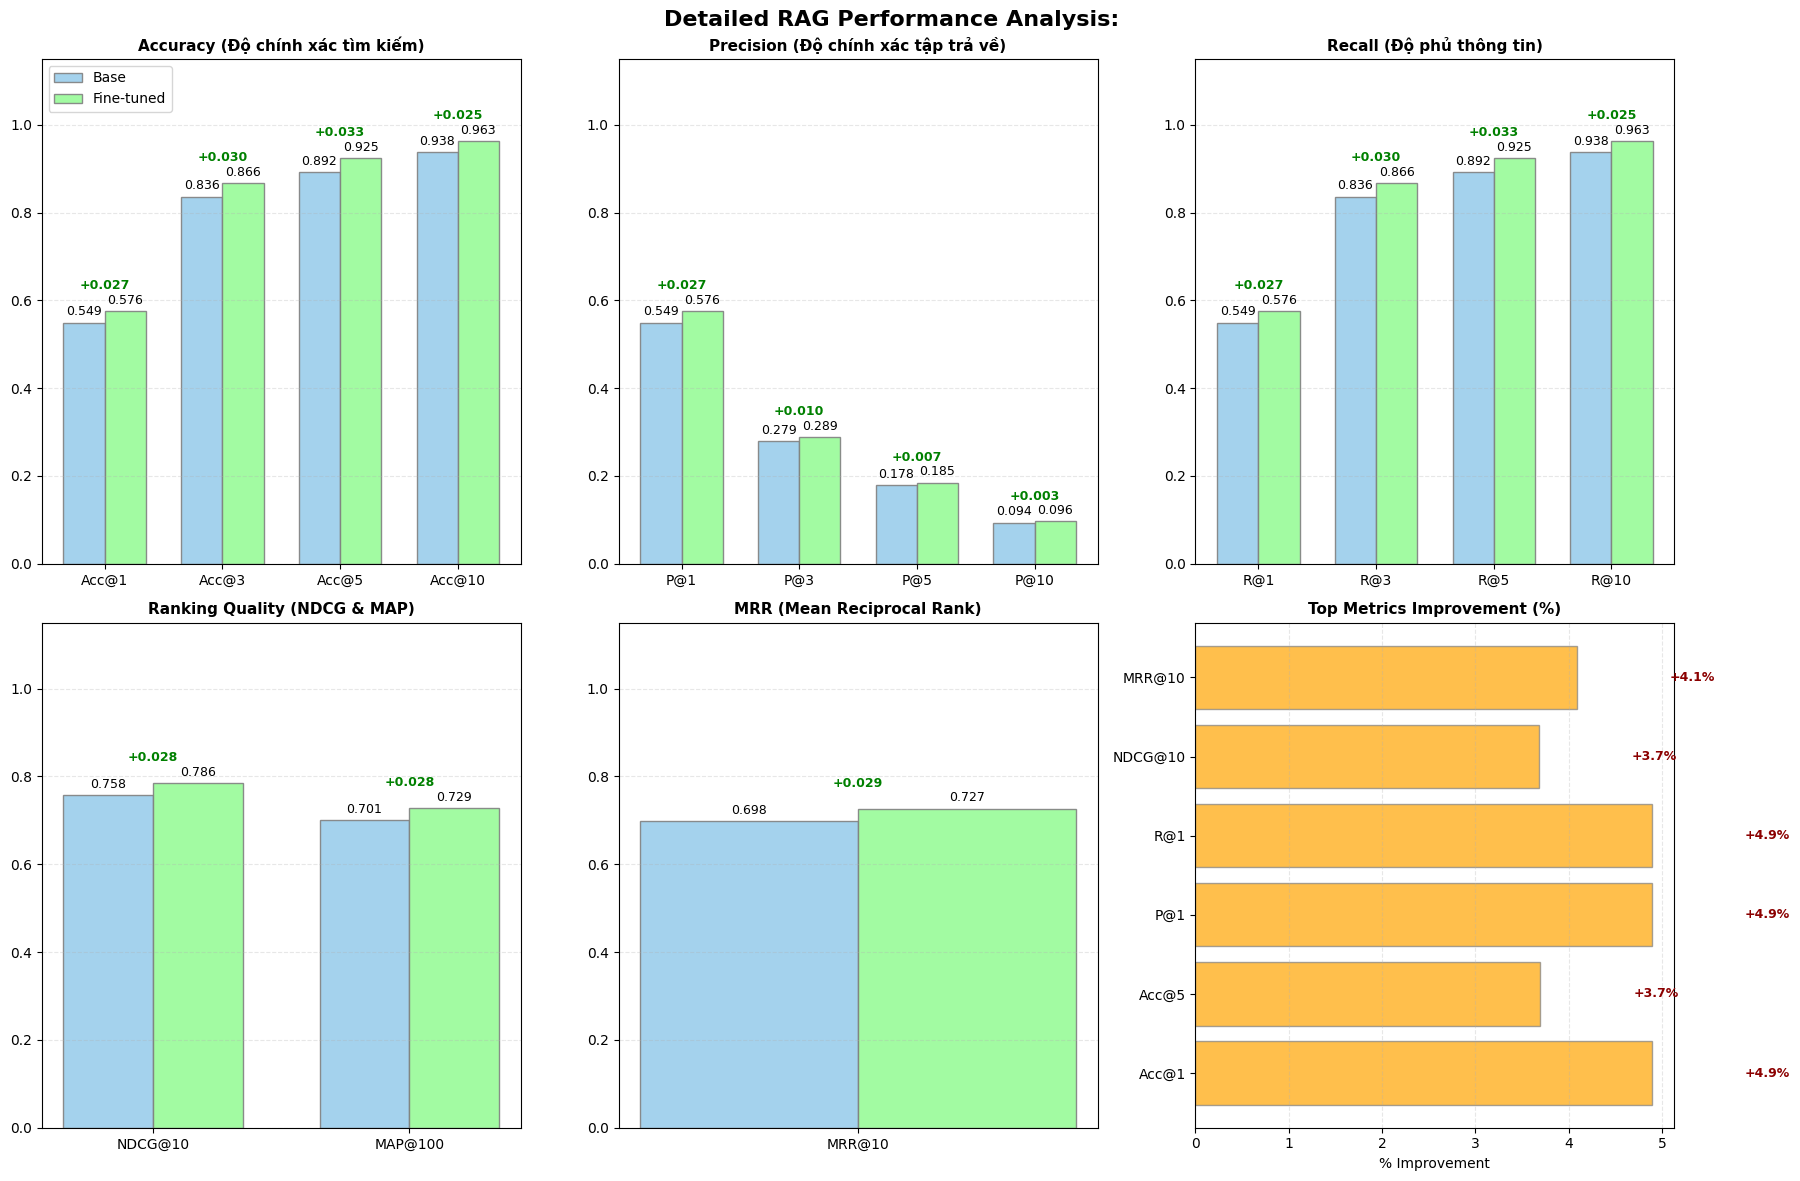

In [ ]:
# =====================================================================
# TRỰC QUAN HÓA CHI TIẾT - 6 BIỂU ĐỒ RIÊNG BIỆT
# =====================================================================
# Mục đích: Vẽ biểu đồ so sánh chi tiết từng nhóm metrics
# Layout: 2 hàng x 3 cột = 6 biểu đồ
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_rag_metrics_separated(res_base, res_ft, evaluator_name="", save_path=None):
    """
    Vẽ 6 biểu đồ riêng biệt để phân tích chi tiết hiệu suất RAG:
    
    1. ACCURACY (Độ chính xác tìm kiếm) - Khả năng tìm được tài liệu đúng trong Top-K
    2. PRECISION (Độ chính xác tập trả về) - Tỷ lệ tài liệu đúng trong K kết quả
    3. RECALL (Độ phủ thông tin) - Tỷ lệ tài liệu đúng được tìm thấy
    4. RANKING QUALITY (Chất lượng xếp hạng) - NDCG & MAP
    5. MRR (Vị trí trung bình kết quả đúng)
    6. TỔNG HỢP CẢI THIỆN (%) - So sánh tổng quan
    
    Args:
        res_base: Dictionary kết quả của Base model
        res_ft: Dictionary kết quả của Fine-tuned model
        evaluator_name: Tên bộ đánh giá (để gắn prefix vào metric keys)
        save_path: Đường dẫn lưu hình (nếu muốn export)
    """

    # 1 CHUẨN BỊ DỮ LIỆU
    prefix = f"{evaluator_name}_" if evaluator_name else ""

    # Định nghĩa các nhóm metrics
    metrics_data = {
        "Accuracy (Độ chính xác tìm kiếm)": [
            ("Acc@1", f"{prefix}cosine_accuracy@1"),   # Tìm đúng ở vị trí 1
            ("Acc@3", f"{prefix}cosine_accuracy@3"),   # Tìm đúng trong Top 3
            ("Acc@5", f"{prefix}cosine_accuracy@5"),   # Tìm đúng trong Top 5
            ("Acc@10", f"{prefix}cosine_accuracy@10")  # Tìm đúng trong Top 10
        ],
        "Precision (Độ chính xác tập trả về)": [
            ("P@1", f"{prefix}cosine_precision@1"),    # Precision tại vị trí 1
            ("P@3", f"{prefix}cosine_precision@3"),    # Precision trong Top 3
            ("P@5", f"{prefix}cosine_precision@5"),    # Precision trong Top 5
            ("P@10", f"{prefix}cosine_precision@10")   # Precision trong Top 10
        ],
        "Recall (Độ phủ thông tin)": [
            ("R@1", f"{prefix}cosine_recall@1"),       # Recall tại vị trí 1
            ("R@3", f"{prefix}cosine_recall@3"),       # Recall trong Top 3
            ("R@5", f"{prefix}cosine_recall@5"),       # Recall trong Top 5
            ("R@10", f"{prefix}cosine_recall@10")      # Recall trong Top 10
        ],
        "Ranking Quality (NDCG & MAP)": [
            ("NDCG@10", f"{prefix}cosine_ndcg@10"),    # Chất lượng xếp hạng
            ("MAP@100", f"{prefix}cosine_map@100")     # Độ chính xác trung bình
        ],
        "MRR (Mean Reciprocal Rank)": [
            ("MRR@10", f"{prefix}cosine_mrr@10")       # Vị trí trung bình kết quả đúng
        ]
    }

    def get_val(res, key):
        """Lấy giá trị metric từ dictionary kết quả"""
        return res.get(key, 0.0)

    # Màu sắc cho biểu đồ
    color_base = '#9ACEEB'  # Xanh dương nhạt (Base Model)
    color_ft = '#98FB98'    # Xanh lá nhạt (Fine-tuned Model)

    # 2 THIẾT LẬP KHUNG HÌNH: 2 hàng x 3 cột
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Detailed RAG Performance Analysis: {evaluator_name}', 
                 fontsize=16, fontweight='bold')

    ax_list = axes.flatten()

    # 3 VẼ 5 BIỂU ĐỒ ĐẦU TIÊN (Từng nhóm metrics)
    all_keys_flat = []

    for i, (title, keys) in enumerate(metrics_data.items()):
        ax = ax_list[i]
        all_keys_flat.extend(keys)

        labels = [k[0] for k in keys]
        base_vals = [get_val(res_base, k[1]) for k in keys]
        ft_vals = [get_val(res_ft, k[1]) for k in keys]

        x = np.arange(len(labels))
        width = 0.35

        # Vẽ cột so sánh
        rects1 = ax.bar(x - width/2, base_vals, width, label='Base', 
                       color=color_base, edgecolor='grey', alpha=0.9)
        rects2 = ax.bar(x + width/2, ft_vals, width, label='Fine-tuned', 
                       color=color_ft, edgecolor='grey', alpha=0.9)

        # Trang trí biểu đồ
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1.15)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        if i == 0: ax.legend(loc='upper left')

        # Hàm ghi giá trị lên đầu cột
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9)

        autolabel(rects1)
        autolabel(rects2)

        # Ghi Delta (Mức cải thiện)
        for j in range(len(labels)):
            improvement = ft_vals[j] - base_vals[j]
            if abs(improvement) > 0.001:
                color = 'green' if improvement > 0 else 'red'
                sign = '+' if improvement > 0 else ''
                ax.text(j, max(base_vals[j], ft_vals[j]) + 0.05,
                        f'{sign}{improvement:.3f}',
                        ha='center', color=color, fontweight='bold', fontsize=9)

    # 4 BIỂU ĐỒ THỨ 6: TỔNG HỢP MỨC ĐỘ CẢI THIỆN (%)
    ax_summary = ax_list[5]

    # Chọn các metrics quan trọng nhất để hiển thị
    summary_keys = [
        ("Acc@1", f"{prefix}cosine_accuracy@1"),
        ("Acc@5", f"{prefix}cosine_accuracy@5"),
        ("P@1", f"{prefix}cosine_precision@1"),
        ("R@1", f"{prefix}cosine_recall@1"),
        ("NDCG@10", f"{prefix}cosine_ndcg@10"),
        ("MRR@10", f"{prefix}cosine_mrr@10")
    ]

    labels_sum = [k[0] for k in summary_keys]
    pct_changes = []

    # Tính % cải thiện
    for _, key_full in summary_keys:
        b = get_val(res_base, key_full)
        f = get_val(res_ft, key_full)
        if b > 0:
            pct = ((f - b) / b) * 100  # Công thức: (Fine - Base) / Base * 100%
        else:
            pct = 0
        pct_changes.append(pct)

    y_pos = np.arange(len(labels_sum))
    
    # Vẽ biểu đồ ngang (horizontal bar)
    ax_summary.barh(y_pos, pct_changes, color='orange', edgecolor='grey', alpha=0.7)
    ax_summary.set_yticks(y_pos)
    ax_summary.set_yticklabels(labels_sum)
    ax_summary.set_xlabel('% Improvement')
    ax_summary.set_title('Top Metrics Improvement (%)', fontsize=11, fontweight='bold')
    ax_summary.grid(axis='x', linestyle='--', alpha=0.3)

    # Ghi giá trị % lên cột
    for i, v in enumerate(pct_changes):
        ax_summary.text(v + (1 if v>=0 else -5), i, f"{v:+.1f}%", 
                       va='center', fontweight='bold', color='darkred', fontsize=9)

    plt.tight_layout()
    plt.show()

# ===== GỌI HÀM VẼ BIỂU ĐỒ =====
eval_name = ir_eval.name if hasattr(ir_eval, 'name') else ""
plot_rag_metrics_separated(res_base, res_ft, eval_name, save_path=None)

print("\n CÁCH ĐỌC BIỂU ĐỒ:")
print("="*70)
print("• Cột xanh dương: Base Model (chưa fine-tune)")
print("• Cột xanh lá: Fine-tuned Model")
print("• Số màu xanh/đỏ phía trên: Mức chênh lệch (+ là tốt hơn, - là kém hơn)")
print("• Biểu đồ cuối (%) cho thấy mức cải thiện tương đối")
print("="*70)

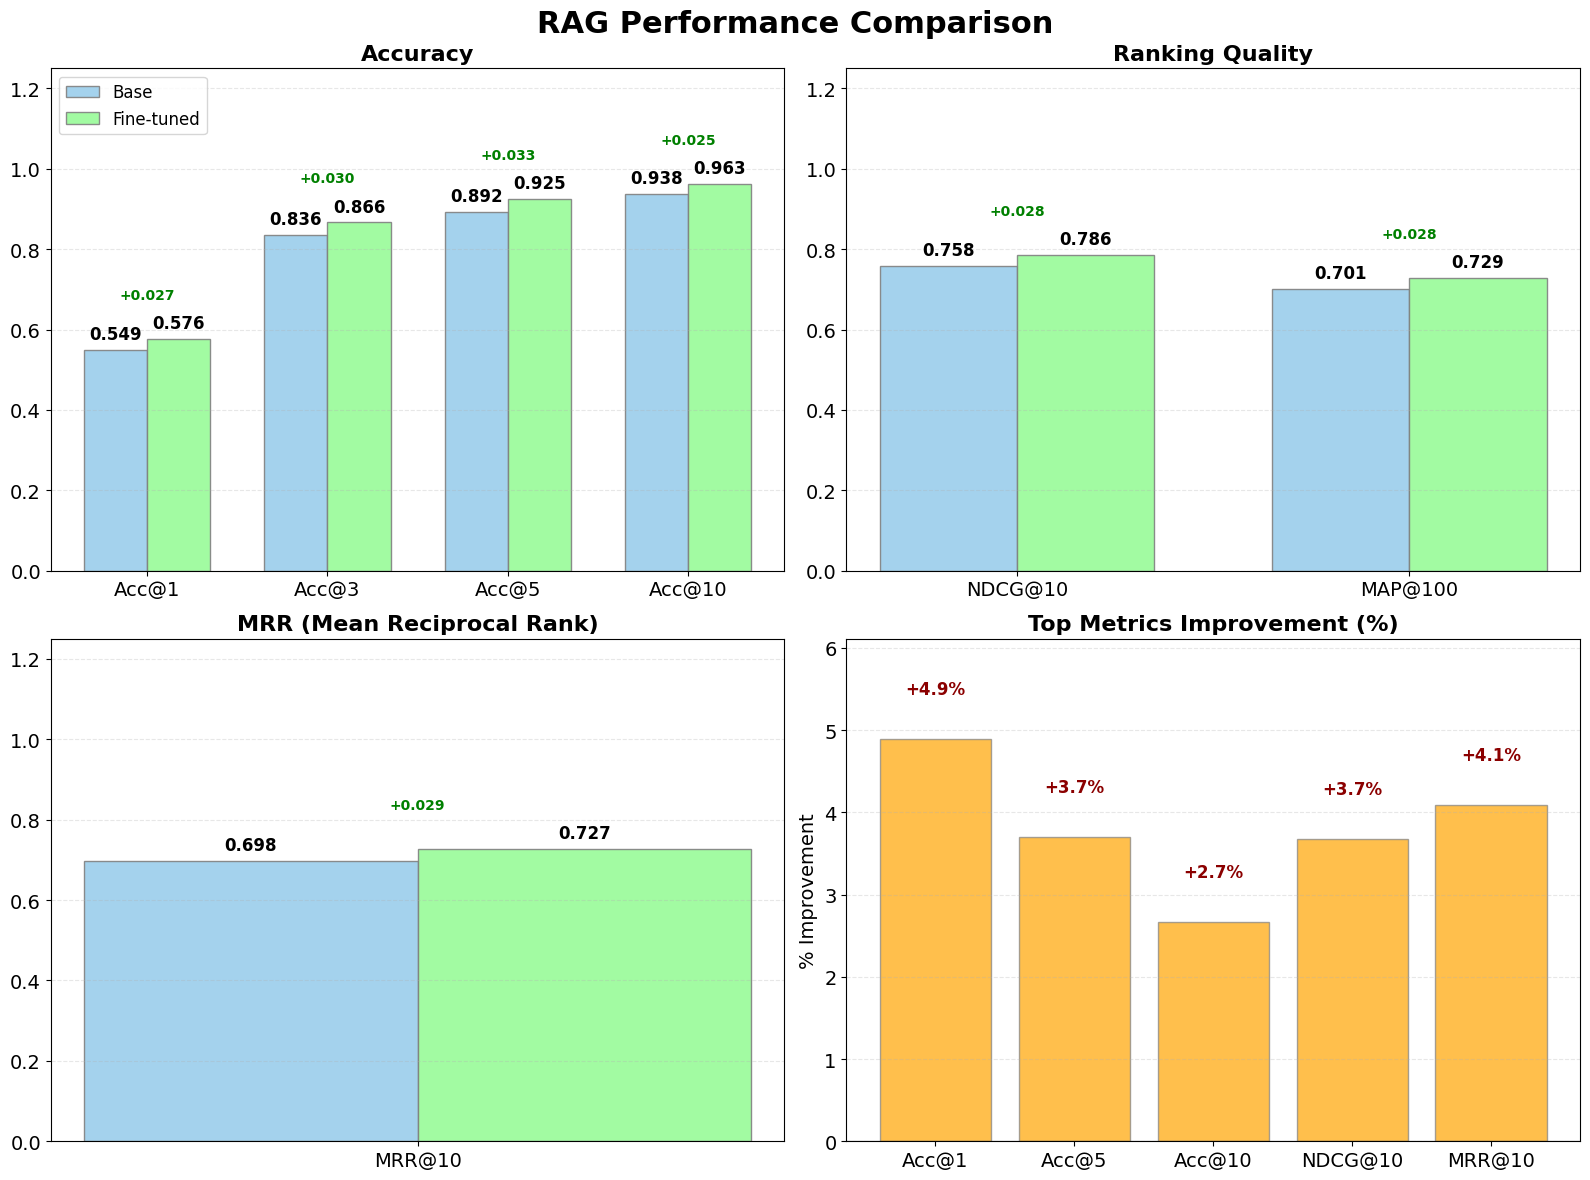

In [ ]:
# =====================================================================
# TRỰC QUAN HÓA TỐI ƯU - 4 BIỂU ĐỒ CHÍNH
# =====================================================================
# Mục đích: Trình bày kết quả gọn gàng, tập trung vào metrics quan trọng
# Layout: 2 hàng x 2 cột = 4 biểu đồ
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_rag_metrics_final(res_base, res_ft, evaluator_name=""):
    """
    Vẽ 4 biểu đồ tối ưu cho báo cáo/thuyết trình:
    
    1. ACCURACY - Độ chính xác tìm kiếm (Acc@1, @3, @5, @10)
       → Khả năng tìm đúng tài liệu trong Top-K
       
    2. RANKING QUALITY - Chất lượng xếp hạng (NDCG@10, MAP@100)
       → Đánh giá thứ tự kết quả trả về có hợp lý không
       
    3. MRR - Mean Reciprocal Rank (MRR@10)
       → Vị trí trung bình của kết quả đúng đầu tiên
       
    4. TỔNG HỢP CẢI THIỆN (%) - So sánh % tăng/giảm
       → Nhìn tổng quan hiệu quả của Fine-tuning
    
    Args:
        res_base: Dict kết quả Base model
        res_ft: Dict kết quả Fine-tuned model
        evaluator_name: Tên dataset/evaluator
    """

    # ==========================================
    # 🎨 CẤU HÌNH CỠ CHỮ (Có thể điều chỉnh)
    # ==========================================
    FONT_VAL_ON_BAR = 12  # Số liệu trên đầu cột
    FONT_AXIS_XY    = 14  # Nhãn trục X, Y
    FONT_TITLE      = 16  # Tiêu đề biểu đồ
    FONT_DELTA      = 10  # Số chênh lệch (Delta)
    FONT_LEGEND     = 12  # Chú thích
    # ==========================================

    # 1️⃣ CHUẨN BỊ DỮ LIỆU
    prefix = f"{evaluator_name}_" if evaluator_name else ""

    def get_val(res, key):
        """Lấy giá trị metric từ dictionary"""
        return res.get(key, 0.0)

    # Định nghĩa 3 nhóm metrics chính
    metrics_data = {
        "Accuracy": [
            ("Acc@1", f"{prefix}cosine_accuracy@1"),
            ("Acc@3", f"{prefix}cosine_accuracy@3"),
            ("Acc@5", f"{prefix}cosine_accuracy@5"),
            ("Acc@10", f"{prefix}cosine_accuracy@10")
        ],
        "Ranking Quality": [
            ("NDCG@10", f"{prefix}cosine_ndcg@10"),
            ("MAP@100", f"{prefix}cosine_map@100")
        ],
        "MRR (Mean Reciprocal Rank)": [
            ("MRR@10", f"{prefix}cosine_mrr@10")
        ]
    }

    # Màu sắc
    color_base = '#9ACEEB'  # Xanh dương nhạt
    color_ft = '#98FB98'    # Xanh lá nhạt

    # 2️⃣ THIẾT LẬP KHUNG HÌNH: 2 hàng x 2 cột
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'RAG Performance Comparison', fontsize=22, fontweight='bold')

    ax_list = axes.flatten()

    # 3️⃣ VẼ 3 BIỂU ĐỒ ĐẦU TIÊN
    for i, (title, keys) in enumerate(metrics_data.items()):
        ax = ax_list[i]

        labels = [k[0] for k in keys]
        base_vals = [get_val(res_base, k[1]) for k in keys]
        ft_vals = [get_val(res_ft, k[1]) for k in keys]

        x = np.arange(len(labels))
        width = 0.35

        # Vẽ cột
        rects1 = ax.bar(x - width/2, base_vals, width, label='Base', 
                       color=color_base, edgecolor='grey', alpha=0.9)
        rects2 = ax.bar(x + width/2, ft_vals, width, label='Fine-tuned', 
                       color=color_ft, edgecolor='grey', alpha=0.9)

        # Trang trí
        ax.set_title(title, fontsize=FONT_TITLE, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1.25)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=FONT_AXIS_XY)

        if i == 0: ax.legend(loc='upper left', fontsize=FONT_LEGEND)

        # Ghi số liệu lên đầu cột
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 5), textcoords="offset points",
                            ha='center', va='bottom',
                            fontsize=FONT_VAL_ON_BAR, fontweight='bold')
        autolabel(rects1)
        autolabel(rects2)

        # Ghi Delta (chênh lệch)
        for j in range(len(labels)):
            diff = ft_vals[j] - base_vals[j]
            if abs(diff) > 0.0001:
                color = 'green' if diff > 0 else 'red'
                sign = '+' if diff > 0 else ''
                ax.text(j, max(base_vals[j], ft_vals[j]) + 0.1,
                        f'{sign}{diff:.3f}', ha='center', color=color, 
                        fontweight='bold', fontsize=FONT_DELTA)

    # 4️⃣ BIỂU ĐỒ THỨ 4: TỔNG HỢP % CẢI THIỆN
    ax_summary = ax_list[3]
    
    # Chọn 5 metrics quan trọng nhất
    summary_keys = [
        ("Acc@1", f"{prefix}cosine_accuracy@1"),
        ("Acc@5", f"{prefix}cosine_accuracy@5"),
        ("Acc@10", f"{prefix}cosine_accuracy@10"),
        ("NDCG@10", f"{prefix}cosine_ndcg@10"),
        ("MRR@10", f"{prefix}cosine_mrr@10")
    ]
    labels_sum = [k[0] for k in summary_keys]
    pct_changes = []

    # Tính % thay đổi: ((Fine - Base) / Base) * 100
    for _, key_full in summary_keys:
        b = get_val(res_base, key_full)
        f = get_val(res_ft, key_full)
        pct = ((f - b) / b) * 100 if b > 0 else 0
        pct_changes.append(pct)

    # Vẽ cột dọc
    x_pos = np.arange(len(labels_sum))
    ax_summary.bar(x_pos, pct_changes, color='orange', edgecolor='grey', alpha=0.7)

    ax_summary.set_xticks(x_pos)
    ax_summary.set_xticklabels(labels_sum)
    ax_summary.set_title('Top Metrics Improvement (%)', fontsize=FONT_TITLE, fontweight='bold')
    ax_summary.set_ylabel('% Improvement', fontsize=FONT_AXIS_XY)
    ax_summary.tick_params(axis='both', labelsize=FONT_AXIS_XY)
    ax_summary.grid(axis='y', linestyle='--', alpha=0.3)
    ax_summary.axhline(0, color='black', linewidth=0.8)  # Vạch ngang tại y=0

    # Ghi số % lên đầu cột
    for i, v in enumerate(pct_changes):
        offset = 0.5 if v >= 0 else -0.5
        va_align = 'bottom' if v >= 0 else 'top'
        color_text = 'darkred' if v >= 0 else 'blue'

        ax_summary.text(i, v + offset, f"{v:+.1f}%",
                        ha='center', va=va_align,
                        fontweight='bold', color=color_text, fontsize=FONT_VAL_ON_BAR)

    # 🔧 FIX: Tự động điều chỉnh ylim để tránh khoảng trắng thừa
    if pct_changes:
        max_val = max(pct_changes) if pct_changes else 0
        min_val = min(pct_changes) if pct_changes else 0

        # Nếu có số âm: Nới rộng cả 2 phía
        if min_val < 0:
            limit_range = max(max_val, abs(min_val)) + 5
            ax_summary.set_ylim(-limit_range, limit_range)
        else:
            # Nếu toàn số dương: Bắt đầu từ 0
            ax_summary.set_ylim(0, max_val * 1.25)

    plt.tight_layout()
    plt.show()

# ===== GỌI HÀM VẼ BIỂU ĐỒ =====
plot_rag_metrics_final(res_base, res_ft)

print("\n" + "="*70)
print("💡 CÁCH ĐỌC BIỂU ĐỒ")
print("="*70)
print("✅ Cột XANH DƯƠNG: Base Model (chưa fine-tune)")
print("✅ Cột XANH LÁ: Fine-tuned Model")
print("✅ Số màu XANH/ĐỎ phía trên: Chênh lệch giữa 2 model")
print("   → Số XANH (+): Model fine-tuned tốt hơn")
print("   → Số ĐỎ (-): Model fine-tuned kém hơn")
print("✅ Biểu đồ cuối (%): Mức cải thiện tương đối")
print("="*70)
print("\n🎯 METRICS QUAN TRỌNG NHẤT CHO RAG:")
print("1. Acc@1: Tìm đúng ngay ở vị trí đầu tiên (ưu tiên số 1)")
print("2. NDCG@10: Thứ tự xếp hạng tốt (thông tin quan trọng ở trên)")
print("3. MRR@10: Kết quả đúng xuất hiện sớm trong danh sách")
print("="*70)